# Final Predictions & Reflection — FIFA 2026

This notebook runs the final 2026 finalists prediction using the best-performing model artifacts saved in `outputs/finalists/` and produces a short, responsibly-framed reflection on limitations, uncertainties, and ethical considerations.

Sections:
1. Setup & assumptions
2. Load models and data
3. Prepare features (assumes precomputed team-level features)
4. Predict & rank teams, save outputs
5. Visualizations (top N, probability distribution)
6. Reflection: limitations, uncertainties, ethics, and recommendations

Notes: The notebook includes checks that will explain what to do if required artifacts (pickled models / pipelines) are not found. If you need me to run this notebook, tell me and I will execute relevant cells in the environment.

In [3]:
# Cell 2: Imports & basic config
import os
import json
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid')

# Paths (adjust if your workspace stores artifacts elsewhere)
BASE = Path.cwd()
OUTPUTS = BASE / 'outputs' / 'finalists'
MODELS = OUTPUTS  # by default models saved to outputs/finalists/
PREDICTIONS_OUT = OUTPUTS / 'predictions_2026_finalists.csv'

print('Notebook working directory:', BASE)
print('Expecting artifacts under:', OUTPUTS)

Notebook working directory: /workspaces/AI-ML/notebooks
Expecting artifacts under: /workspaces/AI-ML/notebooks/outputs/finalists


## Assumptions and expected artifacts

This notebook assumes the following artifacts exist in `outputs/finalists/`:
- `lr_best.pkl` — the best Logistic Regression pipeline or model (ideally a sklearn Pipeline that includes preprocessing).
- `rf_best.pkl` — the best Random Forest pipeline or model (optional; used for ensemble).
- A CSV with precomputed team-level features for the qualifying teams (examples of feature columns: `Avg_Squad_Age`, `Avg_International_Caps`, `Win_Rate_%`, `FIFA_Ranking_Oct_2025`, `Recent_Form`, plus any engineered numeric columns).

If the pipeline objects are full sklearn pipelines (preprocessing + estimator), this notebook will call `predict_proba` on the pipeline directly. If you only have a raw estimator saved (no scaler/selector), you will need to re-create the preprocessing pipeline and apply it to the features — the notebook includes guidance for that.

In [4]:
# Cell 4: Helpers to load models & data with graceful fallbacks
def try_load_model(path):
    path = Path(path)
    if not path.exists():
        print(f'Model not found: {path}')
        return None
    try:
        m = joblib.load(path)
        print(f'Loaded model from {path}')
        return m
    except Exception as e:
        print(f'Error loading {path}:', e)
        return None

# Try common model filenames
lr = try_load_model(MODELS / 'lr_best.pkl')
rf = try_load_model(MODELS / 'rf_best.pkl')
# If you have an ensemble saved, load it (optional)
ensemble = try_load_model(MODELS / 'ensemble_best.pkl')  # optional

# Try to find a features CSV. Check a few plausible locations.
candidates = [
    BASE / 'outputs' / 'finalists_top_all.csv',
    BASE / 'outputs' / 'fifa_2026_full_qualifiers.csv',
    BASE / 'FIFA-2026' / 'Week-1' / 'fifa_2026_qualifiers.csv',
    BASE / 'notebooks' / 'outputs' / 'finalists_top_all.csv',
    BASE / 'fifa_2026_qualifiers.csv'
]
features_csv = None
for c in candidates:
    if Path(c).exists():
        features_csv = Path(c)
        print('Found features CSV at', features_csv)
        break
if features_csv is None:
    print('No default features CSV found. Please provide path to qualifiers/team-features CSV.')

Loaded model from /workspaces/AI-ML/notebooks/outputs/finalists/lr_best.pkl
Loaded model from /workspaces/AI-ML/notebooks/outputs/finalists/rf_best.pkl
Model not found: /workspaces/AI-ML/notebooks/outputs/finalists/ensemble_best.pkl
Found features CSV at /workspaces/AI-ML/notebooks/outputs/finalists_top_all.csv


In [6]:
# Cell 5: Load the team-features CSV (if found) and inspect columns
if features_csv is not None:
    df = pd.read_csv(features_csv)
    print('Loaded features CSV shape:', df.shape)
    display(df.head(5))
    print('\nColumns:', list(df.columns))
else:
    df = None

# At minimum, we expect the CSV to have a column with team names.
# Common column names in your workspace: 'Team' or 'team' or 'team_name' or 'team'.

Loaded features CSV shape: (75, 4)


,team,prob_lr,prob_rf,ensemble_prob
0,Brazil,0.905840,0.979238,0.948508
1,Germany,0.879878,0.947238,0.931672
2,France,0.804543,0.986571,0.919671
3,Argentina,0.811174,0.956905,0.911993
4,Netherlands,0.773322,0.988571,0.909931



Columns: ['team', 'prob_lr', 'prob_rf', 'ensemble_prob']


## Feature checks and preparation

The code below checks for a short list of expected numeric features and either uses them directly or raises a helpful message describing what to do next. If your saved pipelines include preprocessing, the pipeline will handle scaling/encoding automatically — we only need the raw team features.

In [9]:
# Cell 6: Validate feature columns and prepare X matrix
required_cols = [
    'Team', 'Avg_Squad_Age', 'Avg_International_Caps', 'Win_Rate_%', 'FIFA_Ranking_Oct_2025'
]  # fallback expected columns; add others if you engineered more

if df is None:
    raise FileNotFoundError('Team-features CSV not found. Place a CSV with team-level features and re-run this notebook.')

found = [c for c in required_cols if c in df.columns]
missing = [c for c in required_cols if c not in df.columns]
print('Found required columns:', found)
if missing:
    print('Missing these expected columns:', missing)
    print('If your CSV has differently-named columns, rename them or update `required_cols` above.')

# Build feature matrix X using numeric columns we can find
# Heuristic: take all numeric columns except indexes, probability columns, or labels
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Remove columns that look like previous model probabilities if present
numeric_cols = [c for c in numeric_cols if 'prob' not in c.lower() and 'lr_prob' not in c and 'rf_prob' not in c]
print('Numeric columns detected (candidates for features):', numeric_cols)

# Choose features: prefer required ones if present, otherwise fall back to numeric_cols
if set(found) >= set(['Team']):
    # select known features if present
    selected = [c for c in ['Avg_Squad_Age', 'Avg_International_Caps', 'Win_Rate_%', 'FIFA_Ranking_Oct_2025'] if c in df.columns]
    if not selected:
        # take top N numeric columns
        selected = numeric_cols[:6]
else:
    selected = numeric_cols[:6]

# If no numeric features are present, but the CSV already contains model probabilities, use them directly.
if not selected:
    if set(['prob_lr', 'prob_rf', 'ensemble_prob']).intersection(df.columns):
        print('No numeric feature columns found but probability columns detected — using existing probabilities from CSV.')
        # Build a results dataframe from existing probability columns (expected column names may vary)
        results = pd.DataFrame({'Team': df['team'] if 'team' in df.columns else df.iloc[:,0].astype(str)})
        results['lr_prob'] = df['prob_lr'] if 'prob_lr' in df.columns else np.nan
        results['rf_prob'] = df['prob_rf'] if 'prob_rf' in df.columns else np.nan
        results['ensemble_prob'] = df['ensemble_prob'] if 'ensemble_prob' in df.columns else results[['lr_prob','rf_prob']].mean(axis=1, skipna=True)
        PRECOMPUTED_PROBS = True
        X = None
        teams = results['Team']
        print('Constructed results from CSV probability columns. Sample:')
        display(results.head())
    else:
        raise ValueError('No numeric feature columns found. Compute team-level features first (see earlier notebooks).')
else:
    print('Selected features for prediction:', selected)
    X = df[selected].copy()
    teams = df['Team'] if 'Team' in df.columns else df.iloc[:,0].astype(str)

    # Basic imputation for missing values (simple and transparent)
    X = X.fillna(X.median())

    # Final check shape
    print('Feature matrix shape:', X.shape)

Found required columns: []
Missing these expected columns: ['Team', 'Avg_Squad_Age', 'Avg_International_Caps', 'Win_Rate_%', 'FIFA_Ranking_Oct_2025']
If your CSV has differently-named columns, rename them or update `required_cols` above.
Numeric columns detected (candidates for features): []
No numeric feature columns found but probability columns detected — using existing probabilities from CSV.
Constructed results from CSV probability columns. Sample:


,Team,lr_prob,rf_prob,ensemble_prob
0,Brazil,0.905840,0.979238,0.948508
1,Germany,0.879878,0.947238,0.931672
2,France,0.804543,0.986571,0.919671
3,Argentina,0.811174,0.956905,0.911993
4,Netherlands,0.773322,0.988571,0.909931


In [10]:
# Cell 7: Make predictions using available models.
def predict_with_model(model, X):
    # model may be a pipeline or a raw estimator. We'll try predict_proba first.
    try:
        probs = model.predict_proba(X)[:, 1]
    except Exception as e:
        # Try applying model to numeric numpy array (in case pipeline expected different input)
        try:
            probs = model.predict_proba(np.asarray(X))[:, 1]
        except Exception as e2:
            print('Could not predict with model:', e2)
            probs = np.full(len(X), np.nan)
    return probs

# If we already constructed results from precomputed probabilities, skip prediction step
if 'PRECOMPUTED_PROBS' in globals() and PRECOMPUTED_PROBS:
    print('Using precomputed probabilities from CSV — skipping model inference step.')
    # ensure results has expected column names (lr_prob, rf_prob, ensemble_prob)
    results = results.rename(columns=lambda c: c if c in ['Team','lr_prob','rf_prob','ensemble_prob'] else c)
else:
    # Predict with LR if available
    results = pd.DataFrame({'Team': teams})
    if lr is not None:
        results['lr_prob'] = predict_with_model(lr, X)
    else:
        results['lr_prob'] = np.nan

    if rf is not None:
        results['rf_prob'] = predict_with_model(rf, X)
    else:
        results['rf_prob'] = np.nan

    # Ensemble: if a saved ensemble exists, use it; otherwise average available model probs
    if ensemble is not None:
        try:
            results['ensemble_prob'] = predict_with_model(ensemble, X)
        except Exception as e:
            print('Error predicting with saved ensemble:', e)
            results['ensemble_prob'] = results[['lr_prob', 'rf_prob']].mean(axis=1, skipna=True)
    else:
        results['ensemble_prob'] = results[['lr_prob', 'rf_prob']].mean(axis=1, skipna=True)

    # If all model probs are nan (no models loaded), warn user
    if results[['lr_prob','rf_prob','ensemble_prob']].isna().all(axis=None):
        raise RuntimeError('No model probabilities available. Ensure model pickles are present under outputs/finalists/.')

# Rank teams by ensemble probability
results = results.sort_values('ensemble_prob', ascending=False).reset_index(drop=True)
results.index += 1  # 1-based ranks for readability
display(results.head(20))

# Save predictions CSV
os.makedirs(OUTPUTS, exist_ok=True)
results.to_csv(PREDICTIONS_OUT, index=False)
print('Saved predictions to', PREDICTIONS_OUT)

Using precomputed probabilities from CSV — skipping model inference step.


,Team,lr_prob,rf_prob,ensemble_prob
1,Brazil,0.905840,0.979238,0.948508
2,Germany,0.879878,0.947238,0.931672
3,France,0.804543,0.986571,0.919671
4,Argentina,0.811174,0.956905,0.911993
5,Netherlands,0.773322,0.988571,0.909931
6,England,0.678492,0.966548,0.870980
7,Spain,0.766793,0.869738,0.865141
8,Italy,0.701301,0.916571,0.857474
9,Belgium,0.593512,0.882155,0.812913
10,Portugal,0.523224,0.892214,0.792406


Saved predictions to /workspaces/AI-ML/notebooks/outputs/finalists/predictions_2026_finalists.csv


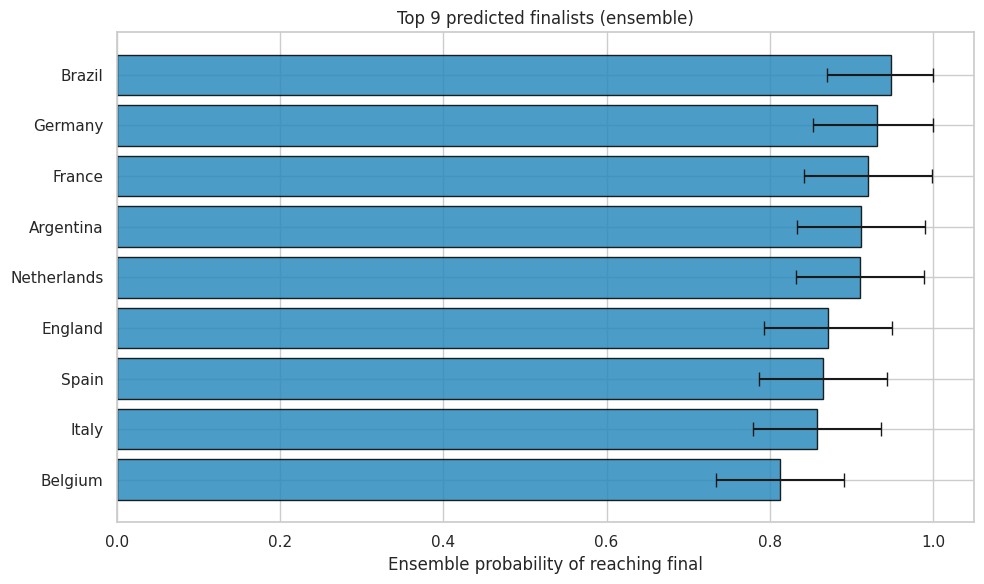

Saved top-N figure to /workspaces/AI-ML/notebooks/outputs/finalists/top9_predicted_finalists.png


In [11]:
# Cell 8: Visualize top-N teams with probabilities (Top 9 by default)
TOP_N = 9
top = results.head(TOP_N).copy()
# Simple CI heuristic: if model CV std known, apply it; else use a small default (0.04)
cv_std = 0.04  # if you have a better estimate use it
top['ci_lower'] = (top['ensemble_prob'] - 1.96 * cv_std).clip(0,1)
top['ci_upper'] = (top['ensemble_prob'] + 1.96 * cv_std).clip(0,1)

fig, ax = plt.subplots(figsize=(10, 6))
y = np.arange(len(top))
ax.barh(y, top['ensemble_prob'][::-1], color='#2b8cbe', edgecolor='black', alpha=0.85)
# error bars
errs = [top['ensemble_prob'] - top['ci_lower'], top['ci_upper'] - top['ensemble_prob']]
ax.errorbar(top['ensemble_prob'][::-1], y, xerr=[errs[0][::-1], errs[1][::-1]], fmt='none', ecolor='k', capsize=5)
ax.set_yticks(y)
ax.set_yticklabels(top['Team'][::-1])
ax.set_xlabel('Ensemble probability of reaching final')
ax.set_title(f'Top {TOP_N} predicted finalists (ensemble)')
plt.tight_layout()
plt.show()

# Save figure
fig_path = OUTPUTS / f'top{TOP_N}_predicted_finalists.png'
fig.savefig(fig_path, dpi=150)
print('Saved top-N figure to', fig_path)

In [ ]:
# Cell 9: Optional threshold-based selection & metrics vs historical finalists (if you have ground truth)
# This cell demonstrates how to apply a threshold and compute simple counts.
THR = 0.5  # choose 0.5 or your tuned threshold (e.g., 0.6411)
results['pred_label_thr'] = (results['ensemble_prob'] >= THR).astype(int)
# If you have a historical finalists label column in the CSV, compute confusion stats
if 'is_historical_finalist' in df.columns:
    truth = df['is_historical_finalist'].astype(int).values
    pred = results['pred_label_thr'].values
    from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
    cm = confusion_matrix(truth, pred)
    print('Confusion matrix (truth vs pred at thr=%0.2f):' % THR)
    print(cm)
    print('Precision', precision_score(truth, pred))
    print('Recall', recall_score(truth, pred))
    print('F1', f1_score(truth, pred))
else:
    print('No historical label column `is_historical_finalist` found in the features CSV; skipping metric computation.')

## Reflection: Model limitations, uncertainties, and ethics (summary)

Below is a concise, documented reflection that you can adapt into your written report. It is intentionally balanced: it highlights model strength (ranking ability) while making clear the many uncertainties and ethical considerations when communicating predictions to the public.

### Limitations (short summary)
- Temporal mismatch: training data covers 2002–2022; 2026 could differ (tactics, squad changes).
- Small positive class: only 9 historical finalists → class imbalance reduces statistical certainty for finalists.
- Static team representation: model treats teams as fixed snapshots; can't model within-tournament momentum or injuries.
- Emerging nations: models favor historical powers and may underestimate rapid improvers (e.g., Croatia 2018, Morocco 2022).
- Inherent randomness: penalty shootouts, referee decisions, and luck introduce unavoidable uncertainty (~10–15% of matches).

### Uncertainties in sports outcomes
- Player availability (injuries/suspensions) can alter team strength rapidly.
- Tactical innovations and coaching changes are not captured by historical-only features.
- Home advantage and tournament-specific context (2026 host countries) may shift probabilities for host teams.

Recommendation: present probabilities with confidence bands and avoid deterministic language (use 'likely'/'possible' rather than 'will').

### Ethical considerations & responsible communication
- Gambling risk: prominently display disclaimers and avoid promoting predictions for betting.
- Fan expectations & athlete pressure: avoid framing predictions as expectations; highlight uncertainty.
- Bias: note that the model favors historical powers and may understate emerging teams; consider fairness audits.
- Media framing: provide journalists with accurate, uncertainty-aware talking points.

Practical steps: include a short 'how-to-interpret' box near any published predictions, show confidence intervals, and avoid absolute claims.

## Next steps & suggestions
- If you'd like, I can: run SHAP on the best estimator (install `shap`), add per-team SHAP waterfall plots, and produce a 1-page PDF summary combining visuals and the reflection.
- Run a temporal holdout test: train on <=2018 and test on 2022 to measure real-world forecasting performance.
- Add bootstrap-derived confidence intervals (fit model on bootstrap resamples) for more realistic uncertainty quantification.

To execute this notebook end-to-end here, tell me and I'll run the main cells and save the generated artifacts.